# CENG463 PA1

In this programming assignment, we want to walk you through the building blocks of natural language processing before the success of neural models. You will be working on text preprocessing, textual data representation methods such as bag-of-words, and traditional ML training pipelines.

You will use Python for this task. You can use libraries such as `pandas`, `nltk`, `scikit-learn` etc. for your implementations, or implement your own functions. However, you are expected to analyse and reason about your implementation and results. 

### IMPORTANT NOTE

Do not move or delete the given cells, only add cells inbetween the questions for your answers.

In [4]:
# UPDATE THIS CELL TO INSTALL NEEDED LIBRARIES.
# MAKE SURE TO ADD EVERYTHING THAT NEEDS TO BE INSTALLED IN THIS CELL!

# we will use pip to install packages - you can add others below
!pip install pandas
!pip install nltk
!pip install scikit-learn
!pip install matplotlib

# and import them here - you can add others below
import pandas as pd
import re
import matplotlib.pyplot as plt
import nltk
from nltk.util import ngrams
import os

## Q1 - Special token extraction with regular expressions (10 points)

Load the `old_tweets.csv` file shared with you. Use regular expressions to capture the following:

- usernames (starting with '@', followed by at least 4, at most 15 alphanumeric characters and '_')
- hashtags (starting with '#' followed by any number of alphanumeric characters)
- numbers (different number notations may be captured, such as "1", ".004", "3:00" and "100,323")
- emojis 

#### Notes and tips

- First tokenizing each tweet by space may be a better approach than using a library tokenizer.
- You can use the [re](https://docs.python.org/3/library/re.html) module to implement your solutions.
- Do not forget to add comments to your code.

In [2]:
# need to combine each column beacuse of 9,31 number format
with open('data/old_tweets.csv', 'r', encoding='utf-8') as f:
    tweets = [line.strip() for line in f]

usernames = []
hashtags = []
numbers = []
emojis = []

In [3]:
# Q1 - implementation
# you can add cells below if needed


In [4]:
def find_usernames(tweet, usernames):
    def is_alphanumeric_or_underscore(s):
        return all(c.isalnum() or c == '_' for c in s)
    candidates = re.findall(r'@(\w+)', tweet)
    for candidate in candidates:
        if(len(candidate) <= 15 and len(candidate) >= 4 and is_alphanumeric_or_underscore(candidate)): #alphanumeric and. _ check
            usernames.append(candidate)

def find_hashtags(tweet, hashtags):
    def is_alphanumeric_or_underscore(s):
        return all(c.isalnum() for c in s)
    candidates = re.findall(r'#(\w+)', tweet)
    for candidate in candidates:
        if(is_alphanumeric_or_underscore(candidate)):
            hashtags.append(candidate)

emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # Emoticons
    "\U0001F300-\U0001F5FF"  # Symbols & pictographs
    "\U0001F680-\U0001F6FF"  # Transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # Flags
    "\U00002700-\U000027BF"  # Dingbats
    "\U0001F900-\U0001F9FF"  # Supplemental Symbols & Pictographs
    "]+",
    flags=re.UNICODE
)

def find_emojis(tweet, emojis):
     emos = emoji_pattern.findall(tweet)
     for emo in emos:
         emojis.append(emo)

def find_numbers(tweet, numbers):
    tokens = tweet.split(" ")
    for token in tokens:
        allowed = "0123456789.,:"
        if all(c in allowed for c in token) and any(c.isdigit() for c in token):
            numbers.append(token)

In [5]:
for tweet in tweets:
    tweet = str(tweet)
    find_usernames(tweet, usernames)
    find_hashtags(tweet, hashtags)
    find_emojis(tweet, emojis)
    find_numbers(tweet, numbers)


In [6]:
print(sorted(usernames))
print(sorted(hashtags))
print(sorted(numbers))
print(sorted(emojis))

['071304Nathan', '143percentspeed', '16_vica', '2minbeachclean', '3gerardpique', 'ABCTV', 'ARTSEDNC', 'AWilliamson54', 'ActionBronson', 'ActuallyNPH', 'AdamBaldwin', 'AdamZHerman', 'Afi_licious', 'Agrivisor', 'Agrivisor', 'AishaRuby85', 'AlanLCross', 'Alanis', 'AlaskaAir', 'AlbinomiteMM4', 'AldridgeSec', 'AlistairBurtUK', 'AlmightyTeemo97', 'AndreSavelio', 'AndrewGoldman_I', 'AnewPerspective', 'AnthonyMuraco', 'AppleSupport', 'AquaRumi9', 'ArriFaun', 'Arron_banks', 'Arsenal', 'Asli_Jacqueline', 'AuSenate', 'AvrilLavigne', 'BBCBreakfast', 'BBCBreaking', 'BBCNews', 'BCFC_Community', 'BLUpfront', 'BWANA86a', 'Bemannn', 'BethRigby', 'BethellMarilyn', 'BettyBowers', 'Bienvenuebrexit', 'BloodMoonSaint', 'Bob_Lawblaw', 'BollyBigBolt', 'Bombardier', 'BradMossEsq', 'BrokenSStudios', 'BroxtonDaniel', 'BryanHoch', 'BugsySeigal', 'ButUCanCallMeZ', 'CBSNews', 'CJamesFelts', 'COFFEECOWal', 'CPC_HQ', 'CakedaddyINTL', 'CamilaLolie97', 'Camila_Cabello', 'CaptainsLog2017', 'CaxtonSupport', 'ChadHoy', 'C

## Q2 - Ngrams and perplexity (40 points)

For this task, you will use the `user_reviews_train.csv` file as a corpus to train N-gram language models for N=1 to N=20. Then you will calculate and plot the following:

- Perplexity scores of the trained N-gram LMs for the first review in `user_reviews_test.csv`
- Perplexity scores of the trained N-gram LMs for `trip_review.txt`, which is a "domain-shift" for our LM.

How does our small model perform? Explain the plots and discuss your findings.

#### Notes and tips

- One approach may be using the [`nltk` LM interface](https://www.nltk.org/api/nltk.lm.api.html#module-nltk.lm.api) to implement the language model and calculate perplexity scores.
- You may follow other approaches, but make sure to explain your work in the discussion and by adding comments in your code.

In [7]:
# Q2 - implementation
# you can add cells below if needed

# used for plots, fill them in accordingly
perplexities_user_review = []
perplexities_trip_review = []

# write your code below

In [8]:
# Load training data

train_data = pd.read_csv('data/user_review_train.csv')
train_corpus = train_data['review'].astype(str).tolist()

test_data = pd.read_csv('data/user_review_test.csv')
test_corpus = test_data['review'].astype(str).tolist()

# Domain shift data read txt file
with open("data/trip_review.txt", "r") as f:
    trip_text = f.read()

In [9]:
len(trip_text), trip_text

(429,
 'Really overpriced and actually nothing more than the caves you can see for free outside of the museum. Most churches were closed anyways and to the special ones you have to again pay a fee even tho you already paid an entry fee to the museum. They also removed all information signs about the caves so that you will buy an additional audio guide. At the entry there are many guide molesting you trying to deceive you into a tour.')

In [10]:
# Clean the text data
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\@\w+|\#','', text) 
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text) # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces
    return text

cleaned_train_corpus = [clean_text(review) for review in train_corpus]
cleaned_test_corpus = [clean_text(review) for review in test_corpus]
cleaned_trip_corpus = clean_text(trip_text).split('\n')


In [11]:
len(cleaned_trip_corpus) , cleaned_trip_corpus

(1,
 ['really overpriced and actually nothing more than the caves you can see for free outside of the museum most churches were closed anyways and to the special ones you have to again pay a fee even tho you already paid an entry fee to the museum they also removed all information signs about the caves so that you will buy an additional audio guide at the entry there are many guide molesting you trying to deceive you into a tour'])

In [12]:
tokenized_train = [nltk.tokenize.word_tokenize(sentence) for sentence in cleaned_train_corpus]
tokenized_test = [nltk.tokenize.word_tokenize(sentence) for sentence in cleaned_test_corpus]
tokenized_trip = [nltk.tokenize.word_tokenize(sentence) for sentence in cleaned_trip_corpus]

len(tokenized_train), len(tokenized_test), len(tokenized_trip)

(14675, 1675, 1)

In [20]:
def flat_ngrams(tokenized, n):
    ngrams_list = [list(ngrams(nltk.lm.preprocessing.pad_both_ends(sentence, n), n)) for sentence in tokenized]
    flat_ngrams = [ng for sent in ngrams_list for ng in sent]
    return flat_ngrams

In [25]:
def trainAndTest(model, perplexities_test, perplexities_trip, N, for_what = ""):
    for n in range(1, N+1):
    # prepare data for this n
    
        flat_train_ngrams = flat_ngrams(tokenized_train, n)
        vocab = nltk.lm.Vocabulary(nltk.lm.preprocessing.flatten(tokenized_train), unk_cutoff=1)
        # train the model
        modell = model(n)
        modell.fit([flat_train_ngrams], vocab)

        # test 1: first review in test.csv
        flat_test_ngrams = flat_ngrams(tokenized_test, n)
        ppl_test = modell.perplexity(flat_test_ngrams)
        perplexities_test.append(ppl_test)

        # test 2: trip review (domain-shift)
        flat_trip_ngrams = flat_ngrams(tokenized_trip, n)
        ppl_trip = modell.perplexity(flat_trip_ngrams)
        perplexities_trip.append(ppl_trip)

        print(f"N={n} | Test perplexity={ppl_test:.2f} | Trip perplexity={ppl_trip:.2f} {for_what}")

In [29]:
perplexities_test = []
perplexities_trip = []

trainAndTest(nltk.lm.Laplace, perplexities_test, perplexities_trip, 20 )

N=1 | Test perplexity=709.82 | Trip perplexity=2386.16 
N=2 | Test perplexity=1376.14 | Trip perplexity=5405.25 
N=3 | Test perplexity=3748.55 | Trip perplexity=14863.29 
N=4 | Test perplexity=4838.10 | Trip perplexity=17159.20 
N=5 | Test perplexity=5119.06 | Trip perplexity=17119.60 
N=6 | Test perplexity=5193.75 | Trip perplexity=17094.16 
N=7 | Test perplexity=5221.35 | Trip perplexity=17077.18 
N=8 | Test perplexity=5238.90 | Trip perplexity=17065.98 
N=9 | Test perplexity=5253.15 | Trip perplexity=17058.95 
N=10 | Test perplexity=5265.42 | Trip perplexity=17055.03 
N=11 | Test perplexity=5276.34 | Trip perplexity=17053.51 
N=12 | Test perplexity=5286.41 | Trip perplexity=17053.88 
N=13 | Test perplexity=5295.79 | Trip perplexity=17055.75 
N=14 | Test perplexity=5304.56 | Trip perplexity=17058.85 
N=15 | Test perplexity=5312.70 | Trip perplexity=17062.94 
N=16 | Test perplexity=5320.29 | Trip perplexity=17067.85 
N=17 | Test perplexity=5327.35 | Trip perplexity=17073.45 
N=18 | Te

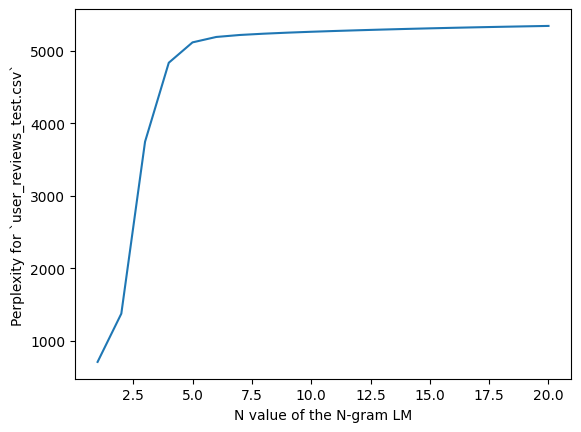

In [30]:
# Q2 - plot for `user_reviews_test.csv`

x = range(1,21,1)
y = perplexities_test

plt.plot(x, y)

plt.xlabel("N value of the N-gram LM")
plt.ylabel("Perplexity for `user_reviews_test.csv`")

plt.show()

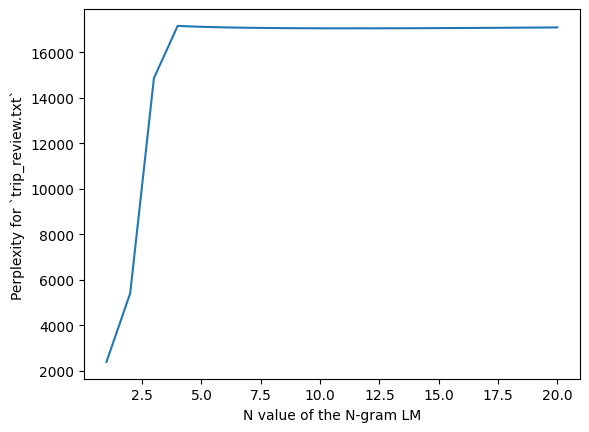

In [31]:
# Q2 - plot for `trip_review.txt`

x = range(1,21,1)
y = perplexities_trip

plt.plot(x, y)

plt.xlabel("N value of the N-gram LM")
plt.ylabel("Perplexity for `trip_review.txt`")

plt.show()

In [32]:
perplexities_test_MLE = []
perplexities_trip_MLE = []

trainAndTest(nltk.lm.MLE, perplexities_test_MLE, perplexities_trip_MLE, 20, "for MLE")

N=1 | Test perplexity=699.86 | Trip perplexity=inf for MLE
N=2 | Test perplexity=42.48 | Trip perplexity=inf for MLE
N=3 | Test perplexity=5.22 | Trip perplexity=inf for MLE
N=4 | Test perplexity=2.12 | Trip perplexity=inf for MLE
N=5 | Test perplexity=1.64 | Trip perplexity=inf for MLE
N=6 | Test perplexity=1.52 | Trip perplexity=inf for MLE
N=7 | Test perplexity=1.48 | Trip perplexity=inf for MLE
N=8 | Test perplexity=1.45 | Trip perplexity=inf for MLE
N=9 | Test perplexity=1.43 | Trip perplexity=inf for MLE
N=10 | Test perplexity=1.41 | Trip perplexity=inf for MLE
N=11 | Test perplexity=1.39 | Trip perplexity=inf for MLE
N=12 | Test perplexity=1.38 | Trip perplexity=inf for MLE
N=13 | Test perplexity=1.36 | Trip perplexity=inf for MLE
N=14 | Test perplexity=1.35 | Trip perplexity=inf for MLE
N=15 | Test perplexity=1.33 | Trip perplexity=inf for MLE
N=16 | Test perplexity=1.32 | Trip perplexity=inf for MLE
N=17 | Test perplexity=1.31 | Trip perplexity=inf for MLE
N=18 | Test perplexi

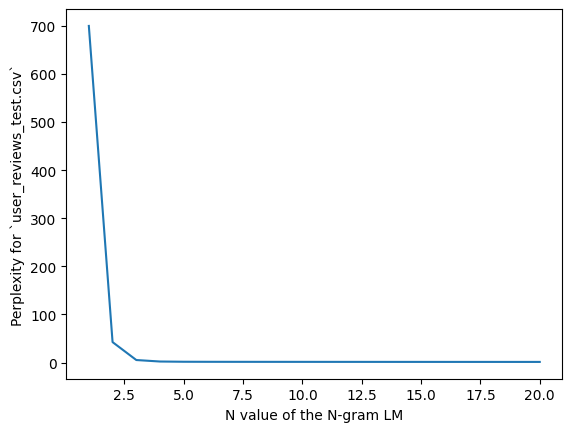

In [33]:
x = range(1,21,1)
y = perplexities_test_MLE

plt.plot(x, y)

plt.xlabel("N value of the N-gram LM")
plt.ylabel("Perplexity for `user_reviews_test.csv`")

plt.show()

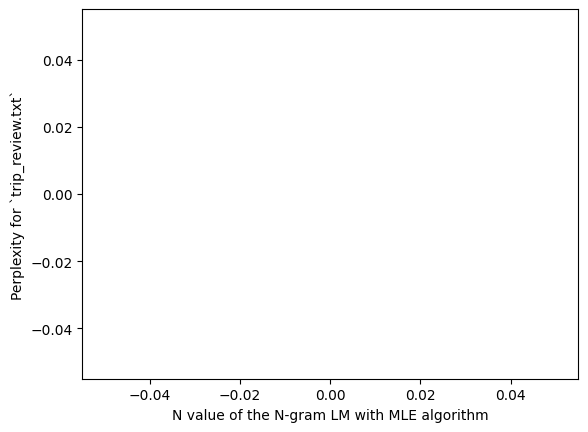

In [34]:
x = range(1,21,1)
y = perplexities_trip_MLE

plt.plot(x, y)

plt.xlabel("N value of the N-gram LM with MLE algorithm")
plt.ylabel("Perplexity for `trip_review.txt`")

plt.show()

### Q2 - Discussion

I implement N-Gram Language Models with different algorithms which are MLE (Maximum Likelihood Estimation) and Laplace.

In both algorithm one can see that how N becomes larger the results become more accurate by monitoring how perplexity score decreases eventually in both algorithms and also in both test and domain-switch cases.

When we compare the algorithms for better performance,

we see that MLE algorithm works fine for our test set and get very low perplexity score at N=20 (1.91) which means that our N-Gram Language Models work fine for our test data. However, we can also see the opposite behaviour at the domain-switch case. Since our model hasn't seen lots of words in the Trip corpus before, the probability score of those unseen words are eventually zero (0) and the perplexity score converges to INFINITY. 

$P(\text{"hotel"} \mid \text{"this was"} = 0)$ 

$$
\text{Perplexity} = 2^{ - \frac{1}{N} \sum \log_2 P(w_i \mid context) }
$$

If any $P(w_i \mid context) = 0$, then $\log P(w_i \mid context) = -\infty$.

On the other hand, the Laplace algorithm puts some smoothing to this perplexity calculation so that we got more clever results for unseen words but this brings trade-offs for our test corpus. One can see higher perplexity score than MLE algorithm for test corpus.

$$
P(w_i \mid context) = \frac{count(context, w_i) + 1}{count(context) + V}
$$

My choice is Laplace theorem actually.

#### Why Laplace Is the Right Choice Here

In this assignment, we train **20 separate language models (N = 1 → 20)** on a relatively **small dataset** (`user_reviews_train.csv`).

For large N (e.g., N > 5), the number of possible n-grams grows exponentially, and many combinations are **never seen** in training.

That means:

- **MLE models** will assign **many zero probabilities**, leading to **infinite perplexities**.
- **Laplace models** will keep results **stable and comparable** across N values.

Thus, **Laplace smoothing** is a **practical and safe choice** for this assignment.


## Q3 - Classifying user reviews using Bag-of-Words (50 points)

For this final task, you will use the `user_reviews_train.csv` and `user_reviews_test.csv` files to implement a binary classifier with Bag-of-Words representation. 

The given dataset includes user reviews and corresponding `sentiment` value for each review, either `1` meaning positive or `0` meaning negative. With this dataset, you are expected to implement a classifier that decides whether a given user review is positive or negative. 

### Part A - Analysis

In this part, you will analyse the training set given in the `user_reviews_train.csv` file to answer these questions:

- How many instances are there for each class?
- What is the minimum, maximum, and average character length of the reviews?
- Does the average length of a review depend heavily on the class label?
- Any other statistics you can report with minimal processing?

You can use tables or draw plots to show your analyses.

### Part B - Implementation

The goal of this part is not to get the highest possible performance, but to see the effect of changing the text representation. Hence, you will train six models: 

- `lighlty_preprocessed_most_15`
- `lighlty_preprocessed_most_100`
- `fully_preprocessed_most_15`
- `fully_preprocessed_most_100`
- `fully_preprocessed_most_500`
- `fully_preprocessed_least_15`

For the `lighlty_preprocessed_most_N` models, the preprocessing steps are as follows:

- Tokenize the reviews by separating from whitespaces.
- Lowercase all tokens for normalization.
- Order all unique tokens by frequency, take the most frequently used N.
- Use these N words as the corpus for Bag-of-Words representation.

For the `fully_preprocessed_most_N` models, the preprocessing steps are as follows:

- Tokenize the reviews by using `word_tokenize()` from `nltk.tokenize`.
- Lowercase all tokens for normalization.
- Remove stopwords by using `stopwords` from `nltk.corpus`.
- Apply lematization to tokens by using `WordNetLemmatizer` from `nltk.stem`. 
- Order all unique tokens by frequency, take the most frequently used N.
- Use these N words as the corpus for Bag-of-Words representation.

For the `fully_preprocessed_least_15` model, the preprocessing steps are as follows:

- Tokenize the reviews by using `word_tokenize()` from `nltk.tokenize`.
- Lowercase all tokens for normalization.
- Remove stopwords by using `stopwords` from `nltk.corpus`.
- Apply lematization to tokens by using `WordNetLemmatizer` from `nltk.stem`. 
- Order all unique tokens by frequency, take the **LEAST** frequently used 15.
- Use these 15 words as the corpus for Bag-of-Words representation.

For all six models, after preprocessing, you should implement the model obeying the following:

- You must to use Bag-of-Words representation to represent each data instance. You can use `CountVectorizer` from `scikit-learn` or any other library available to implement this.
- You should select a classification method from the following set of classifiers: `[Naive Bayes, Support Vector Machine, Logistic Regression, Random Forest]`. You can use `scikit-learn`, `nltk`, or any other library for the classifier implementations. 
- You should **not** use the test set `user_reviews_test.csv` during your training process. You should use `user_reviews_train.csv` only.
- You may add a validation step in your training process. To do this, you can further split the `user_reviews_train.csv` data and apply k-fold cross validation.
- You should analyse the performance of your models with four metrics on the test set `user_reviews_test.csv`: accuracy, precision, recall and F1-score.

Do not forget to add any additional libraries you used to the `pip` installations.

### Part C - Performance discussion

In this part, you will report the performance of your models with the four metrics mentioned in Part A. You should discuss your findings. Which model performed better, and why is that the case? Is it the expected result, or a surprising one? Discuss the results in detail. For the models with a corpus of length 15, make sure to add the corpus to your discussion.


In [12]:
# Q3 PART A - Analysis

# you can add cells below if needed
review_trains = pd.read_csv('data/user_review_train.csv')
review_test = pd.read_csv('data/user_review_test.csv')
positive_reviews = review_trains[review_trains['sentiment'] == 1]
negative_reviews = review_trains[review_trains['sentiment'] == 0]

# How many positive and negative reviews are there in the training set?
num_positive_reviews = len(positive_reviews)
num_negative_reviews = len(negative_reviews)
num_positive_reviews, num_negative_reviews

(6963, 7712)

In [6]:
# find min and max and avg review lengths
def findMaxMinAvgLengths(review_trains):
    review_lengths = review_trains.apply(lambda x: len(str(x).split()))
    min_length = review_lengths.min()
    max_length = review_lengths.max()
    avg_length = review_lengths.mean()
    return min_length, max_length, avg_length

positive_reviews_lMin, positive_reviews_lMax, positive_reviews_lAvg = findMaxMinAvgLengths(positive_reviews)
negative_reviews_lMin, negative_reviews_lMax, negative_reviews_lAvg = findMaxMinAvgLengths(negative_reviews)

# Let's print the results
print(f"Positive Reviews - Min Length: {positive_reviews_lMin}, Max Length: {positive_reviews_lMax}, Avg Length: {positive_reviews_lAvg:.2f}")
print(f"Negative Reviews - Min Length: {negative_reviews_lMin}, Max Length: {negative_reviews_lMax}, Avg Length: {negative_reviews_lAvg:.2f}")

Positive Reviews - Min Length: 27, Max Length: 90, Avg Length: 58.50
Negative Reviews - Min Length: 27, Max Length: 84, Avg Length: 55.50


### Thoughts about lengths

As we see that minimum, maximum and average length of both positive and negative reviews are almost same. So that it doesn't give any clue about for such classification task.

In [7]:
# Q3 PART B - Implementation

# you can add cells below if needed
def tokenizeBySpace(text):
    return text.split()

def tokenizeFull(text):
    return nltk.tokenize.word_tokenize(text)

def lowerCase(text):
    return text.lower()

nltk.download('stopwords')
def removeStopwords(text):
    stop_words = set(nltk.corpus.stopwords.words('english'))
    return ' '.join([word for word in text.split() if word not in stop_words])

def lemitaizeText(text):
    lemmatizer = nltk.stem.WordNetLemmatizer()
    return ' '.join([lemmatizer.lemmatize(word) for word in text.split()])


[nltk_data] Downloading package stopwords to /Users/ovak/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
from collections import Counter
import time

def preprocess_data(reviews_df, N, frequency='most', strength='lightly'):
    """
    Preprocess reviews and return processed texts and vocabulary.
    
    Parameters:
    - reviews_df: DataFrame with 'review' column
    - N: number of words to select for vocabulary
    - frequency: 'most' or 'least' frequent words
    - strength: 'lightly' or 'fully' preprocessed
    
    Returns:
    - processed_reviews: list of preprocessed review strings
    - vocabulary: list of N selected words
    """
    
    processed_reviews = []
    all_tokens = []
    start_time = time.time()
    for review in reviews_df['review']:
        text = str(review)
        
        # Apply lowercase
        text = lowerCase(text)
        
        # Tokenize based on strength
        if strength == 'lightly':
            # Light preprocessing: split by whitespace
            tokens = tokenizeBySpace(text)
        else:  # strength == 'fully'
            # Full preprocessing: use word_tokenize
            tokens = tokenizeFull(text)
            
            # Remove stopwords
            text_no_stop = removeStopwords(' '.join(tokens))
            
            # Lemmatize
            text_lemmatized = lemitaizeText(text_no_stop)
            
            tokens = text_lemmatized.split()
        
        # Store processed text and tokens
        processed_reviews.append(' '.join(tokens))
        all_tokens.extend(tokens)
    
    # Count token frequencies
    token_counts = Counter(all_tokens)
    
    # Select N tokens based on frequency
    if frequency == 'most':
        # Get the N most common tokens
        selected_tokens = [token for token, count in token_counts.most_common(N)]
    else:  # frequency == 'least'
        # Get the N least common tokens
        selected_tokens = [token for token, count in token_counts.most_common()[:-N-1:-1]] 
    
    vocabulary = selected_tokens
    print(f" {strength}_preprocessed_{frequency}_{N} is ready! (Time: {start_time})")
    return processed_reviews, vocabulary


In [19]:
lightly_preprocessed_most_15 = preprocess_data(review_trains, N=15, frequency='most', strength='lightly')
lightly_preprocessed_most_100 = preprocess_data(review_trains, N=100, frequency='most', strength='lightly')
fully_preprocessed_most_15 = preprocess_data(review_trains, N=15, frequency='most', strength='fully')
fully_preprocessed_most_100 = preprocess_data(review_trains, N=100, frequency='most', strength='fully')
fully_preprocessed_most_500 = preprocess_data(review_trains, N=500, frequency='most', strength='fully')
fully_preprocessed_least_15 = preprocess_data(review_trains, N=15, frequency='least', strength='fully')

# push each one to library as name and preprocessed data
preprocessed_dic = {}
preprocessed_dic["lightly_preprocessed_most_15"] = lightly_preprocessed_most_15
preprocessed_dic["lightly_preprocessed_most_100"] = lightly_preprocessed_most_100
preprocessed_dic["fully_preprocessed_most_15"] = fully_preprocessed_most_15
preprocessed_dic["fully_preprocessed_most_100"] = fully_preprocessed_most_100
preprocessed_dic["fully_preprocessed_most_500"] = fully_preprocessed_most_500
preprocessed_dic["fully_preprocessed_least_15"] = fully_preprocessed_least_15

 lightly_preprocessed_most_15 is ready! (Time: 1762339796.8969789)
 lightly_preprocessed_most_100 is ready! (Time: 1762339796.9421911)
 fully_preprocessed_most_15 is ready! (Time: 1762339796.975013)
 fully_preprocessed_most_100 is ready! (Time: 1762339798.41401)
 fully_preprocessed_most_500 is ready! (Time: 1762339799.8737879)
 fully_preprocessed_least_15 is ready! (Time: 1762339801.318957)


In [10]:
from sklearn.feature_extraction.text import CountVectorizer

def get_bow_features(processed_reviews, vocabulary):
    """
    Convert processed reviews into Bag-of-Words features using a fixed vocabulary.
    """
    vectorizer = CountVectorizer(vocabulary=vocabulary)
    X = vectorizer.fit_transform(processed_reviews)
    return X

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def train_and_evaluate(X_train, y_train, X_test, y_test, model=LogisticRegression(max_iter=1000), model_name="Model"):
    """
    Train Logistic Regression on Bag-of-Words features and evaluate.
    """
    if isinstance(model, GaussianNB):
            X_train = X_train.toarray()
            X_test = X_test.toarray()
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f":D) {model_name} Results:")
    print(f"Accuracy: {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall: {rec:.3f}")
    print(f"F1-score: {f1:.3f}\n")
    
    return acc, prec, rec, f1


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

def testPreprocessedWModel(model):
    results = []
    for name, preprocessed in preprocessed_dic.items():
        processed_reviews, vocab = preprocessed 
        
        # Train/test split
        X_train = get_bow_features(processed_reviews, vocab)
        y_train = review_trains['sentiment']
        
        # Preprocess test set
        processed_test_reviews, _ = preprocess_data(review_test, N=len(vocab), frequency='most', strength='fully')
        X_test = get_bow_features(processed_test_reviews, vocab)
        y_test = review_test['sentiment']
        
        # Evaluate
        acc, prec, rec, f1 = train_and_evaluate(X_train, y_train, X_test, y_test, model, model_name=name)
        
        results.append({
            'Preprocessing': name,
            'Model': type(model).__name__,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1
        })
        
    return results

In [36]:
all_results = []

model_list = [
    LogisticRegression(max_iter=1000),
    RandomForestClassifier(n_estimators=100, random_state=42),
    svm.SVC(kernel='linear'),
    GaussianNB()
]

for model in model_list:
    all_results.extend(testPreprocessedWModel(model))

# Convert to DataFrame for easy comparison
results_df = pd.DataFrame(all_results)
results_df


 fully_preprocessed_most_15 is ready! (Time: 1762342924.464293)
:D) lightly_preprocessed_most_15 Results:
Accuracy: 0.621
Precision: 0.609
Recall: 0.952
F1-score: 0.743

 fully_preprocessed_most_100 is ready! (Time: 1762342924.702362)
:D) lightly_preprocessed_most_100 Results:
Accuracy: 0.759
Precision: 0.730
Recall: 0.924
F1-score: 0.815

 fully_preprocessed_most_15 is ready! (Time: 1762342924.918946)
:D) fully_preprocessed_most_15 Results:
Accuracy: 0.658
Precision: 0.683
Recall: 0.757
F1-score: 0.718

 fully_preprocessed_most_100 is ready! (Time: 1762342925.123748)
:D) fully_preprocessed_most_100 Results:
Accuracy: 0.813
Precision: 0.829
Recall: 0.850
F1-score: 0.840

 fully_preprocessed_most_500 is ready! (Time: 1762342925.3467689)
:D) fully_preprocessed_most_500 Results:
Accuracy: 0.853
Precision: 0.876
Recall: 0.867
F1-score: 0.872

 fully_preprocessed_most_15 is ready! (Time: 1762342925.588437)
:D) fully_preprocessed_least_15 Results:
Accuracy: 0.425
Precision: 0.000
Recall: 0.0

/Users/ovak/Documents/dev/METU-CENG/CENG463/PA1/student_pack/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


 fully_preprocessed_most_15 is ready! (Time: 1762342925.806741)
:D) lightly_preprocessed_most_15 Results:
Accuracy: 0.620
Precision: 0.611
Recall: 0.929
F1-score: 0.738

 fully_preprocessed_most_100 is ready! (Time: 1762342927.023977)
:D) lightly_preprocessed_most_100 Results:
Accuracy: 0.768
Precision: 0.744
Recall: 0.910
F1-score: 0.818

 fully_preprocessed_most_15 is ready! (Time: 1762342929.003177)
:D) fully_preprocessed_most_15 Results:
Accuracy: 0.689
Precision: 0.698
Recall: 0.808
F1-score: 0.749

 fully_preprocessed_most_100 is ready! (Time: 1762342929.747298)
:D) fully_preprocessed_most_100 Results:
Accuracy: 0.920
Precision: 0.911
Recall: 0.954
F1-score: 0.932

 fully_preprocessed_most_500 is ready! (Time: 1762342931.412574)
:D) fully_preprocessed_most_500 Results:
Accuracy: 0.958
Precision: 0.957
Recall: 0.970
F1-score: 0.963

 fully_preprocessed_most_15 is ready! (Time: 1762342933.729981)
:D) fully_preprocessed_least_15 Results:
Accuracy: 0.426
Precision: 1.000
Recall: 0.00

,Preprocessing,Model,Accuracy,Precision,Recall,F1-Score
0,lightly_preprocessed_most_15,LogisticRegression,0.620896,0.608898,0.952233,0.742811
1,lightly_preprocessed_most_100,LogisticRegression,0.759403,0.729508,0.924195,0.815392
2,fully_preprocessed_most_15,LogisticRegression,0.657910,0.682584,0.757009,0.717873
3,fully_preprocessed_most_100,LogisticRegression,0.813134,0.828947,0.850467,0.839569
4,fully_preprocessed_most_500,LogisticRegression,0.853134,0.876180,0.867082,0.871608
5,fully_preprocessed_least_15,LogisticRegression,0.425075,0.000000,0.000000,0.000000
6,lightly_preprocessed_most_15,RandomForestClassifier,0.619701,0.611339,0.929387,0.737536
7,lightly_preprocessed_most_100,RandomForestClassifier,0.767761,0.743633,0.909657,0.818309
8,fully_preprocessed_most_15,RandomForestClassifier,0.688955,0.698384,0.807892,0.749157
9,fully_preprocessed_most_100,RandomForestClassifier,0.920000,0.910803,0.954309,0.932049


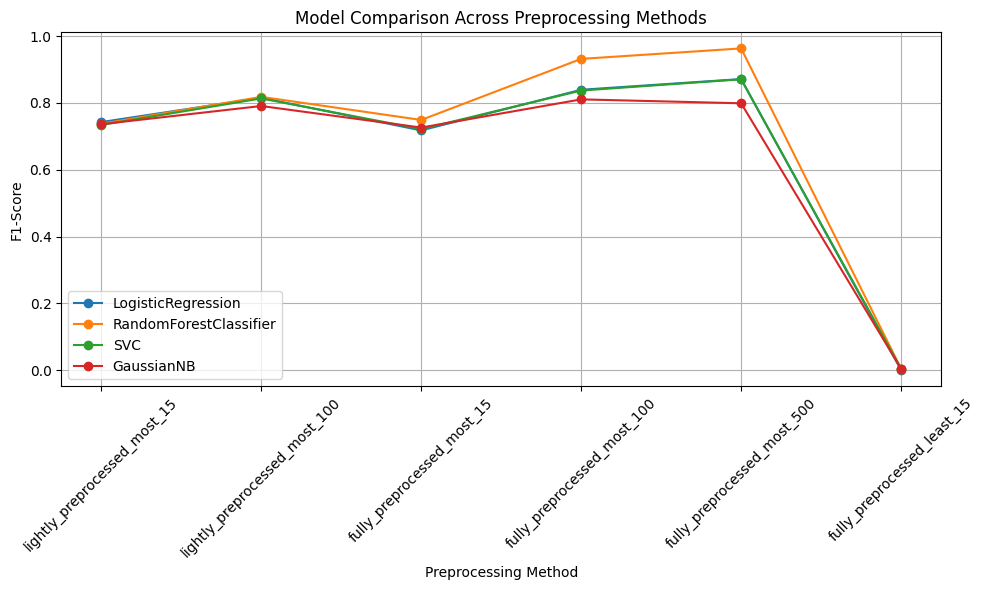

In [37]:
plt.figure(figsize=(10,6))
for model_name in results_df['Model'].unique():
    subset = results_df[results_df['Model'] == model_name]
    plt.plot(subset['Preprocessing'], subset['F1-Score'], marker='o', label=model_name)

plt.title('Model Comparison Across Preprocessing Methods')
plt.xlabel('Preprocessing Method')
plt.ylabel('F1-Score')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


### Q3 PART C - Performance discussion

Write your discussion here.

As we discuss the concept Bag-of-Words. We test different preprocessed data extracted from our training dataset. Different classifiers (such as logistic regression, svc, gauissian, random forest etc.) fet by each preprocessed data to find out the best classifier for our case and see the results from different preproccession process. 

As we see that using most relevant words for our "Bag" gives high accuracy models as expected since there is huge F1-score drop in fully_preprocessd_least_15. 

### Impact of Vocabulary Size (N):

- Also the number of words (N) also effects the performance of the models wheter it is fully or lightly preprocessed. This is evident from f1 scores where N grows from 15 to 500

- It can be monitored that there is overperformance where N is higher than 15. Altough increasing the N results more accuracy, this relation is not linear. While larger values provide more features fro the model the improvement stop as N becomes very large. Because, at some point the accuracy converges to 1. For example, the performance difference between N=100 and N=500 is smaller compared to the difference between N=15 and N=100. This suggests that after a certain point, adding more words to the vocabulary has diminishing returns.

- Therefore, chosing N value as 100 is the key point to balance the performance and computational load. 

#### Fully vs. Lightly Preprocessed Data:
- For fully or slightly preprocessing, there is no strong evidence whether fully preprocessing gives better results or not. Only difference accours at the most_100 cases for randomforest classifier. 

#### Classifier Comparison:

- Among the classifiers, Random Forest consistently outperforms others, achieving the highest F1-scores, especially for larger vocabulary sizes (e.g., N=100 and N=500). This is likely due to its ability to handle high-dimensional data and capture complex patterns.

- Logistic Regression and SVC also perform well, particularly for fully preprocessed data with N=100 or more. 

- But the Gaussian perform the worst performance amoung those 4 models. 

### To sum up

- Using the most frequent words for the Bag-of-Words representation is crucial for achieving high accuracy and F1-scores. Models trained on the least frequent words fail to generalize and perform poorly.

- Fully preprocessing the data provides a slight edge in performance, but lightly preprocessed data can still yield competitive results, especially for larger vocabularies.

- The choice of classifier also plays a significant role, with Random Forest emerging as the most robust option across different preprocessing methods and vocabulary sizes.